## STEP 1 — LOAD AND UNDERSTAND DATA

This cell imports the `pandas` library, which is essential for working with tabular data in Python. It then reads your uploaded CSV file, `regenerated_landslide_risk_dataset.csv`, into a DataFrame named `df`. Finally, it displays the first 5 rows of your dataset, giving you a quick preview of its structure and content.

In [5]:
import pandas as pd
import requests
# Read the uploaded CSV file into a DataFrame named 'df'
df = pd.read_csv('/Users/kafi/Downloads/regenerated_landslide_risk_dataset.csv')

print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,Temperature (°C),Humidity (%),Precipitation (mm),Soil Moisture (%),Elevation (m),Landslide Risk Prediction
0,17,68,176,64,120,Low
1,26,33,65,24,672,Low
2,16,81,56,52,36,Low
3,25,53,136,70,583,Low
4,34,77,23,37,130,Low


After viewing the beginning of the dataset, it's good practice to also check the end. This cell displays the last 5 rows of your DataFrame `df`.

In [6]:
print('Last 5 rows of the dataset:')
display(df.tail())

Last 5 rows of the dataset:


,Temperature (°C),Humidity (%),Precipitation (mm),Soil Moisture (%),Elevation (m),Landslide Risk Prediction
4995,30,74,60,72,103,Low
4996,26,95,26,51,541,Low
4997,19,79,223,82,30,Low
4998,26,39,62,53,768,Low
4999,23,30,125,61,526,Low


This cell provides the dimensions of your DataFrame. `df.shape` returns a tuple where the first element is the number of rows and the second is the number of columns. This helps you understand the size of your dataset.

In [7]:
print(f'Number of rows and columns: {df.shape}')

Number of rows and columns: (5000, 6)


It's crucial to know the exact names of your columns. This cell prints a list of all column names in your DataFrame. This helps verify that the column names match your expectations or identify any discrepancies.

In [8]:
print('Column names:')
print(df.columns.tolist())

Column names:
['Temperature (°C)', 'Humidity (%)', 'Precipitation (mm)', 'Soil Moisture (%)', 'Elevation (m)', 'Landslide Risk Prediction']


This cell uses `df.info()` to display a concise summary of the DataFrame, including the data type of each column and the number of non-null values. Understanding data types is essential for proper data manipulation and analysis (e.g., ensuring numerical operations are performed on numerical columns).

In [9]:
print('Data types and non-null values:')
df.info()

Data types and non-null values:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Temperature (°C)           5000 non-null   int64
 1   Humidity (%)               5000 non-null   int64
 2   Precipitation (mm)         5000 non-null   int64
 3   Soil Moisture (%)          5000 non-null   int64
 4   Elevation (m)              5000 non-null   int64
 5   Landslide Risk Prediction  5000 non-null   str  
dtypes: int64(5), str(1)
memory usage: 250.9 KB


The `df.describe()` method generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution for numerical columns. This includes count, mean, standard deviation, min, max, and quartile values. For categorical columns, it provides count, unique, top, and frequency. This gives you a quick overview of the statistical properties of your data.

In [10]:
print('Basic statistical information:')
display(df.describe(include='all'))

Basic statistical information:


,Temperature (°C),Humidity (%),Precipitation (mm),Soil Moisture (%),Elevation (m),Landslide Risk Prediction
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000
unique,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,Low
freq,NaN,NaN,NaN,NaN,NaN,4591
mean,24.815800,62.614000,123.126400,54.915800,503.015800,NaN
std,6.052867,19.108533,72.144734,20.345788,288.700745,NaN
min,15.000000,30.000000,0.000000,20.000000,0.000000,NaN
25%,20.000000,46.000000,61.000000,37.000000,253.000000,NaN
50%,25.000000,63.000000,121.000000,55.000000,505.000000,NaN
75%,30.000000,79.000000,186.000000,72.250000,757.000000,NaN


This block iterates through each column of your DataFrame and prints all unique values present in that column. This is particularly useful for categorical columns to identify all possible categories and for numerical columns to spot any unexpected or erroneous values.

In [11]:
print('Unique values for each column:')
for col in df.columns:
    print(f'\n--- Column: {col} ---')
    print(df[col].unique())

Unique values for each column:

--- Column: Temperature (°C) ---
[17 26 16 25 34 15 35 28 21 32 24 27 23 31 20 30 18 19 33 29 22]

--- Column: Humidity (%) ---
[68 33 81 53 77 84 89 41 62 30 66 31 76 56 90 72 55 67 49 80 51 43 45 70
 35 36 38 48 95 37 47 91 42 32 57 40 52 87 65 86 88 44 73 50 64 79 59 71
 61 46 85 93 83 82 69 63 58 78 92 60 74 75 94 39 54 34]

--- Column: Precipitation (mm) ---
[176  65  56 136  23  70 208 147  86  41  80 214   6 116  91  15 144 217
  64   7 106 115 107 143 184  71  55  77 124 175 114 194 233  69  59 174
 193 243 118 157  39 237 199  27 239 159  49 152 230  96 196 131 250  58
 151 186  54 125 238 112 109 132  76 212 185 110  48  67 234  78  57  83
 129  99 149 197   5  62  19   1 127 209  12 121 202 226  38 222 164 224
 211  68  72  84  35 241 139 161 167 150  16 219  73 220 102 204  50   8
  98  10  87 134  81  95 101  21  88  14 247 213 108 244 195  94 111 182
  97  18 221 155 192 218  53 171 104 168 154  13 117 206 210 198 179 158
 138  31 160 123  

Knowing the number of unique values helps assess the cardinality of each feature. This cell calculates and displays the count of unique values for every column in the DataFrame. High numbers of unique values in categorical columns might suggest a need for different encoding strategies, while low numbers in numerical columns might indicate limited variation.

In [12]:
print('Number of unique values in each column:')
for col in df.columns:
    print(f'{col}: {df[col].nunique()}')

Number of unique values in each column:
Temperature (°C): 21
Humidity (%): 66
Precipitation (mm): 251
Soil Moisture (%): 71
Elevation (m): 993
Landslide Risk Prediction: 4


This cell focuses on your target variable, 'Landslide Risk Prediction'. It first displays all unique risk categories present in the dataset and then calculates the frequency (count) and percentage of each category. This helps in understanding the distribution of your target classes and whether there is any class imbalance, which is critical for machine learning tasks.

In [13]:
TARGET_COLUMN = 'Landslide Risk Prediction'

print(f'Target column: {TARGET_COLUMN}')

print('\nUnique target classes:')
print(df[TARGET_COLUMN].unique())

print('\nTarget class frequencies (counts):')
display(df[TARGET_COLUMN].value_counts())

print('\nTarget class frequencies (percentages):')
display(df[TARGET_COLUMN].value_counts(normalize=True) * 100)

Target column: Landslide Risk Prediction

Unique target classes:
<ArrowStringArray>
['Low', 'Moderate', 'High', 'Very High']
Length: 4, dtype: str

Target class frequencies (counts):


Landslide Risk Prediction
Low          4591
Moderate      334
High           63
Very High      12
Name: count, dtype: int64


Target class frequencies (percentages):


Landslide Risk Prediction
Low          91.82
Moderate      6.68
High          1.26
Very High     0.24
Name: proportion, dtype: float64

## STEP 4 — EXPLORATORY DATA ANALYSIS

First, we import the necessary libraries for plotting: `matplotlib.pyplot` for basic plotting functionalities and `seaborn` for enhanced statistical visualizations. These will be used to create all the plots in this EDA section.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots for better aesthetics
sns.set_style("whitegrid")

### Feature Distribution Visualizations

These plots will help us understand the spread and characteristics of individual environmental features.

This histogram visualizes the distribution of 'Temperature (°C)'. It shows how frequently different temperature ranges occur in the dataset. Observing the shape of the distribution can tell us if temperatures are normally distributed, skewed, or if there are any unusual peaks or gaps.

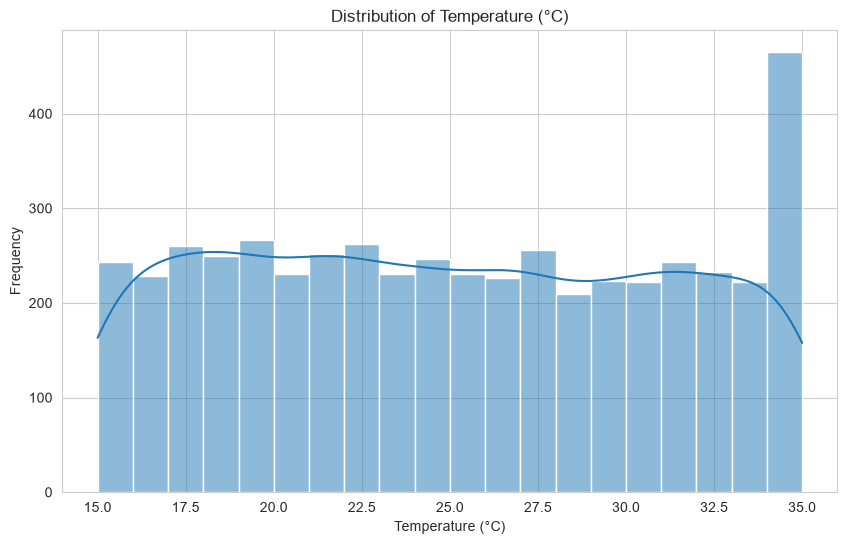

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Temperature (°C)'], kde=True, bins=20)
plt.title('Distribution of Temperature (°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

This histogram shows the distribution of 'Humidity (%)'. Similar to temperature, it helps us understand the typical humidity levels and their variability within the dataset. We can identify if humidity values are concentrated in certain ranges or if they are spread out evenly.

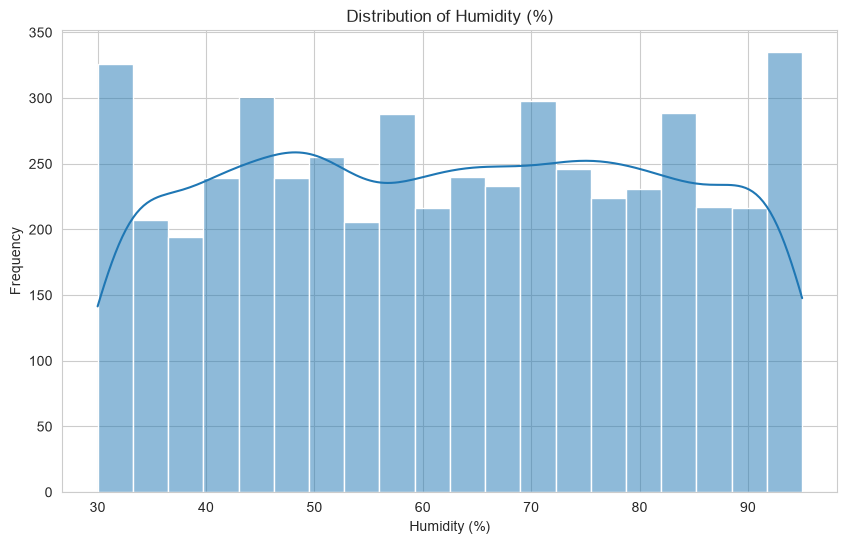

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Humidity (%)'], kde=True, bins=20)
plt.title('Distribution of Humidity (%)')
plt.xlabel('Humidity (%)')
plt.ylabel('Frequency')
plt.show()

The distribution of 'Precipitation (mm)' is visualized here. This is a critical factor for landslides. We can see if precipitation is generally low with occasional high values, or if it has a more even distribution. This can highlight periods of heavy rainfall that might contribute to landslide risk.

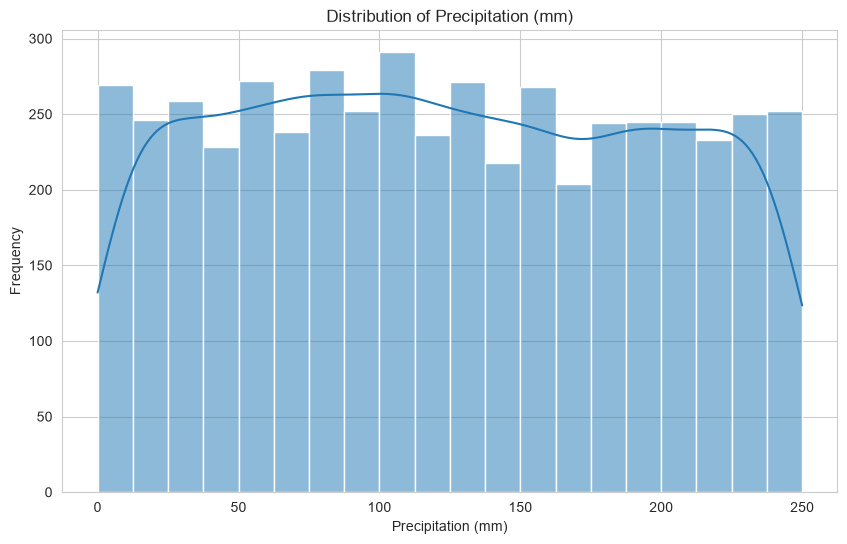

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Precipitation (mm)'], kde=True, bins=20)
plt.title('Distribution of Precipitation (mm)')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency')
plt.show()

This plot shows the distribution of 'Soil Moisture (%)'. Soil moisture is directly related to soil stability. The histogram helps us understand the range and common levels of soil moisture, and whether there are instances of very high soil saturation that could indicate higher risk.

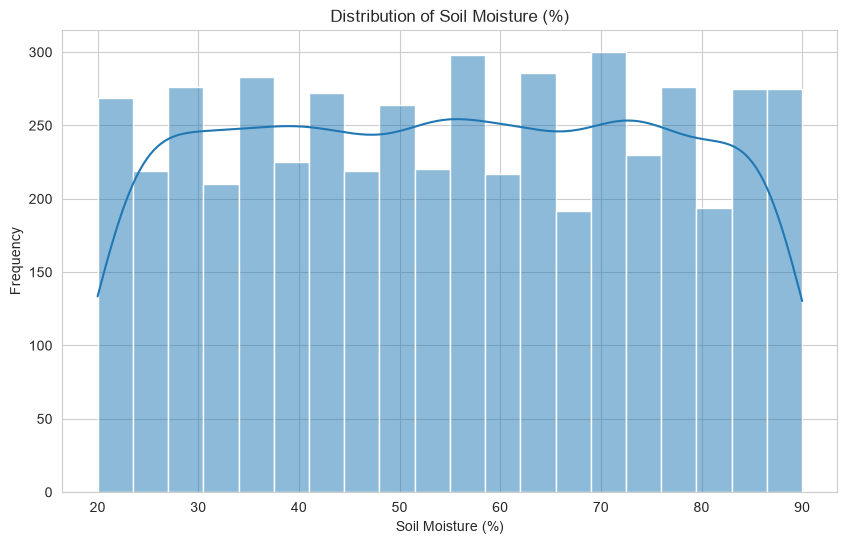

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Soil Moisture (%)'], kde=True, bins=20)
plt.title('Distribution of Soil Moisture (%)')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Frequency')
plt.show()

The histogram for 'Elevation (m)' illustrates the range of altitudes present in your dataset. This can indicate if the data primarily comes from low-lying areas, mountainous regions, or a mix. Elevation is an important topographical factor influencing landslide susceptibility.

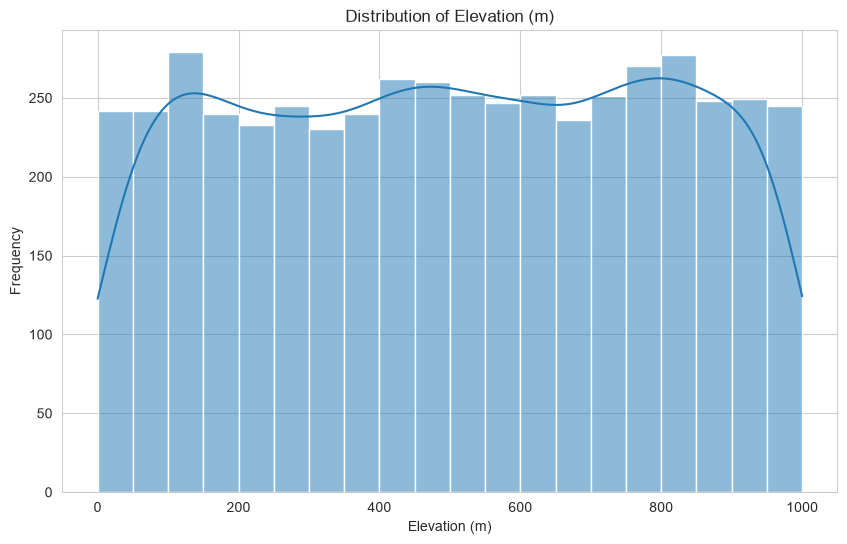

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Elevation (m)'], kde=True, bins=20)
plt.title('Distribution of Elevation (m)')
plt.xlabel('Elevation (m)')
plt.ylabel('Frequency')
plt.show()

This bar plot shows the distribution of your target variable, 'Landslide Risk Prediction'. It visually confirms the counts and proportions of each risk category (Low, Moderate, High, Very High), reinforcing the information we saw earlier with `value_counts()` and highlighting any class imbalance.

/var/folders/jt/zbm1n0v94ll4cws_yx8z89fh0000gn/T/ipykernel_3136/1141952554.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=TARGET_COLUMN, order=df[TARGET_COLUMN].value_counts().index, palette='viridis')


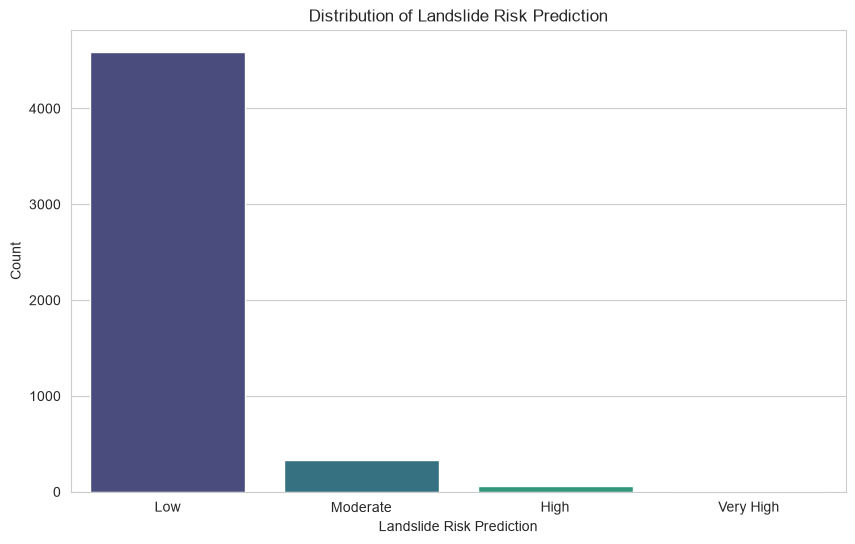

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=TARGET_COLUMN, order=df[TARGET_COLUMN].value_counts().index, palette='viridis')
plt.title('Distribution of Landslide Risk Prediction')
plt.xlabel('Landslide Risk Prediction')
plt.ylabel('Count')
plt.show()

### Relationships Between Features and Landslide Risk

These box plots will help us understand how the distribution of each environmental feature varies across different landslide risk categories. This can reveal potential correlations and insights into which factors are more associated with higher landslide risk.

This box plot shows the relationship between 'Precipitation (mm)' and 'Landslide Risk Prediction'. Each box represents the distribution of precipitation for a given risk level. We can observe if higher precipitation values are generally associated with higher landslide risk categories, which would be expected.

/var/folders/jt/zbm1n0v94ll4cws_yx8z89fh0000gn/T/ipykernel_3136/3624866233.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COLUMN, y='Precipitation (mm)', order=['Low', 'Moderate', 'High', 'Very High'], palette='coolwarm')


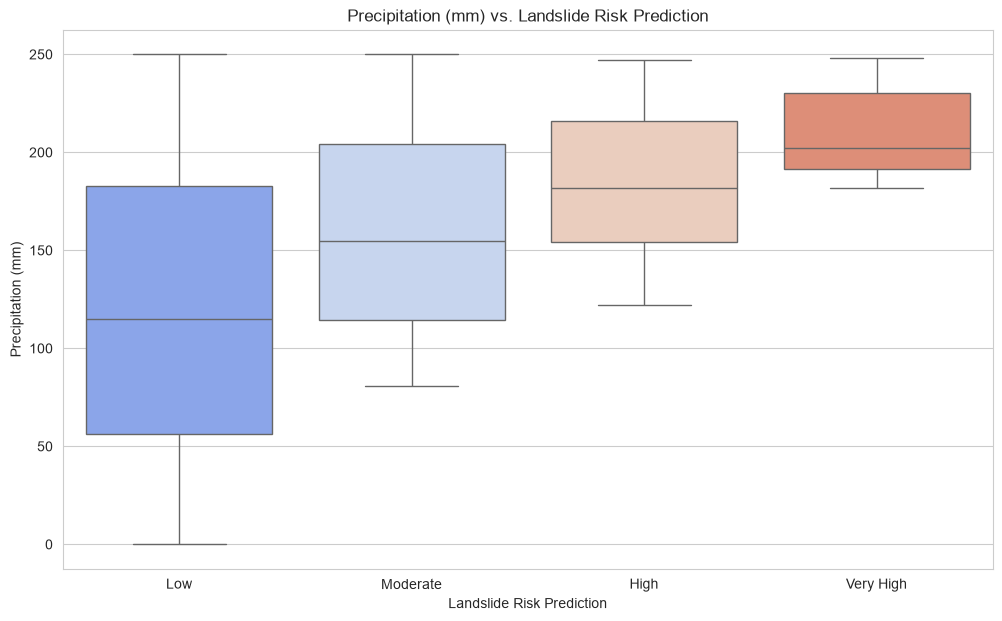

In [21]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x=TARGET_COLUMN, y='Precipitation (mm)', order=['Low', 'Moderate', 'High', 'Very High'], palette='coolwarm')
plt.title('Precipitation (mm) vs. Landslide Risk Prediction')
plt.xlabel('Landslide Risk Prediction')
plt.ylabel('Precipitation (mm)')
plt.show()

Here, we visualize the relationship between 'Soil Moisture (%)' and 'Landslide Risk Prediction'. This plot can reveal if increasing soil moisture levels correspond to a higher likelihood of landslide risk. Saturated soil is less stable, so we might expect to see higher soil moisture values for 'High' and 'Very High' risk categories.

/var/folders/jt/zbm1n0v94ll4cws_yx8z89fh0000gn/T/ipykernel_3136/1728403574.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COLUMN, y='Soil Moisture (%)', order=['Low', 'Moderate', 'High', 'Very High'], palette='coolwarm')


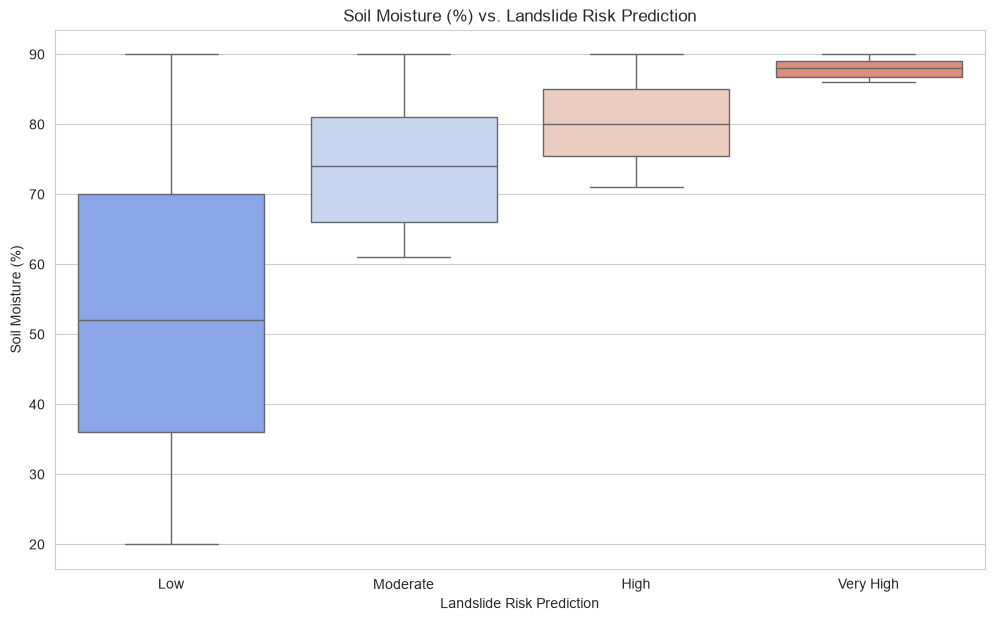

In [22]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x=TARGET_COLUMN, y='Soil Moisture (%)', order=['Low', 'Moderate', 'High', 'Very High'], palette='coolwarm')
plt.title('Soil Moisture (%) vs. Landslide Risk Prediction')
plt.xlabel('Landslide Risk Prediction')
plt.ylabel('Soil Moisture (%)')
plt.show()

This box plot illustrates the relationship between 'Humidity (%)' and 'Landslide Risk Prediction'. While humidity might not be as directly impactful as precipitation or soil moisture, high humidity can sometimes accompany conditions that lead to landslides. This plot helps us see if there's any noticeable pattern.

/var/folders/jt/zbm1n0v94ll4cws_yx8z89fh0000gn/T/ipykernel_3136/3983198817.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COLUMN, y='Humidity (%)', order=['Low', 'Moderate', 'High', 'Very High'], palette='coolwarm')


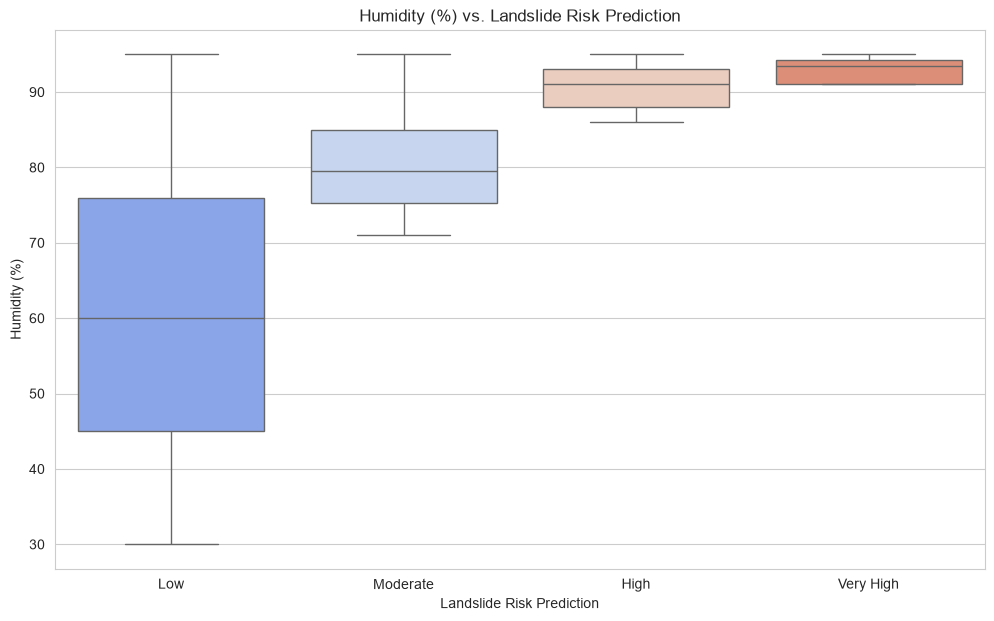

In [23]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x=TARGET_COLUMN, y='Humidity (%)', order=['Low', 'Moderate', 'High', 'Very High'], palette='coolwarm')
plt.title('Humidity (%) vs. Landslide Risk Prediction')
plt.xlabel('Landslide Risk Prediction')
plt.ylabel('Humidity (%)')
plt.show()

The relationship between 'Temperature (°C)' and 'Landslide Risk Prediction' is shown in this box plot. Temperature might have indirect effects on soil stability (e.g., freeze-thaw cycles), or it might correlate with other factors like rainfall intensity. This plot helps us identify if certain temperature ranges are more prevalent in higher risk scenarios.

/var/folders/jt/zbm1n0v94ll4cws_yx8z89fh0000gn/T/ipykernel_3136/974733866.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COLUMN, y='Temperature (°C)', order=['Low', 'Moderate', 'High', 'Very High'], palette='coolwarm')


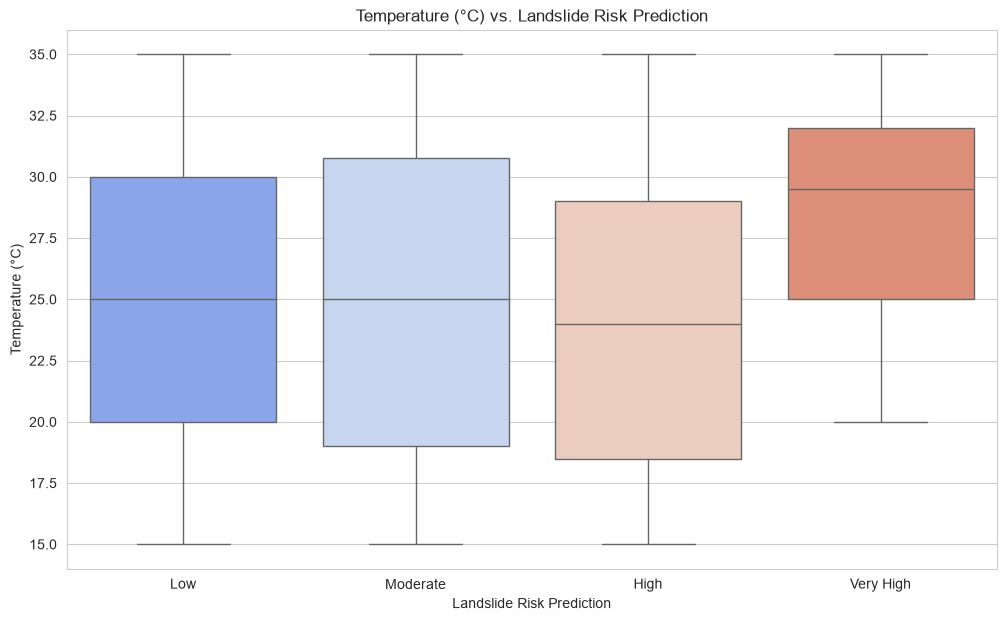

In [24]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x=TARGET_COLUMN, y='Temperature (°C)', order=['Low', 'Moderate', 'High', 'Very High'], palette='coolwarm')
plt.title('Temperature (°C) vs. Landslide Risk Prediction')
plt.xlabel('Landslide Risk Prediction')
plt.ylabel('Temperature (°C)')
plt.show()

This box plot examines 'Elevation (m)' against 'Landslide Risk Prediction'. Landslides often occur in sloped or elevated terrains. We would anticipate that higher risk categories might be associated with higher or more varied elevation ranges, though elevation alone doesn't tell us about the slope.

/var/folders/jt/zbm1n0v94ll4cws_yx8z89fh0000gn/T/ipykernel_3136/2159865705.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_COLUMN, y='Elevation (m)', order=['Low', 'Moderate', 'High', 'Very High'], palette='coolwarm')


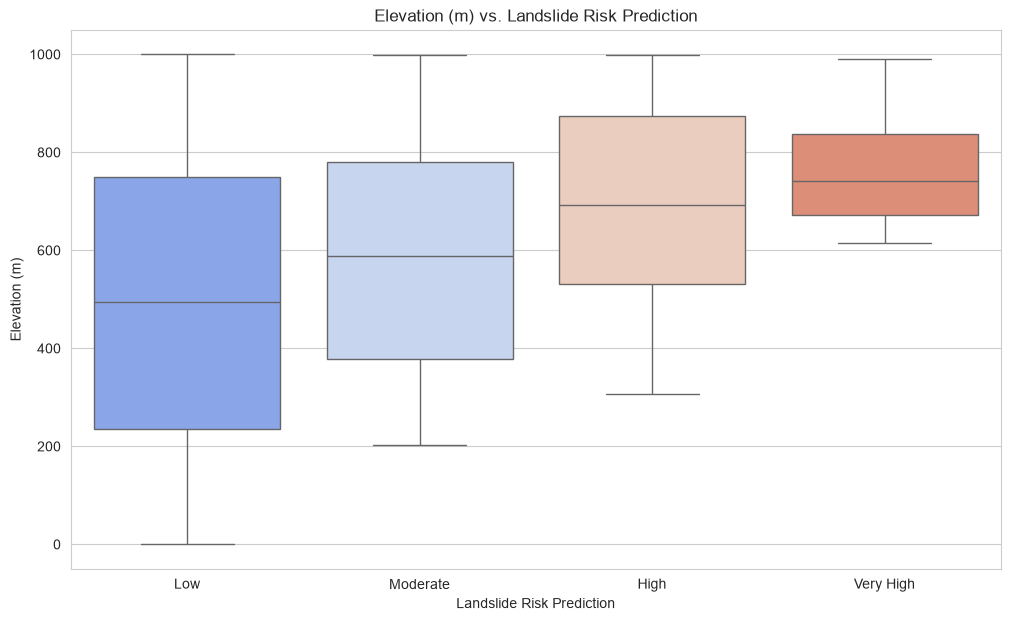

In [25]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x=TARGET_COLUMN, y='Elevation (m)', order=['Low', 'Moderate', 'High', 'Very High'], palette='coolwarm')
plt.title('Elevation (m) vs. Landslide Risk Prediction')
plt.xlabel('Landslide Risk Prediction')
plt.ylabel('Elevation (m)')
plt.show()

### Correlation Heatmap

This heatmap visualizes the Pearson correlation coefficients between all numerical variables in your dataset. Correlation measures the linear relationship between two variables. A value close to 1 indicates a strong positive correlation, -1 indicates a strong negative correlation, and 0 indicates no linear correlation. It's important to remember that **correlation does not imply causation**.

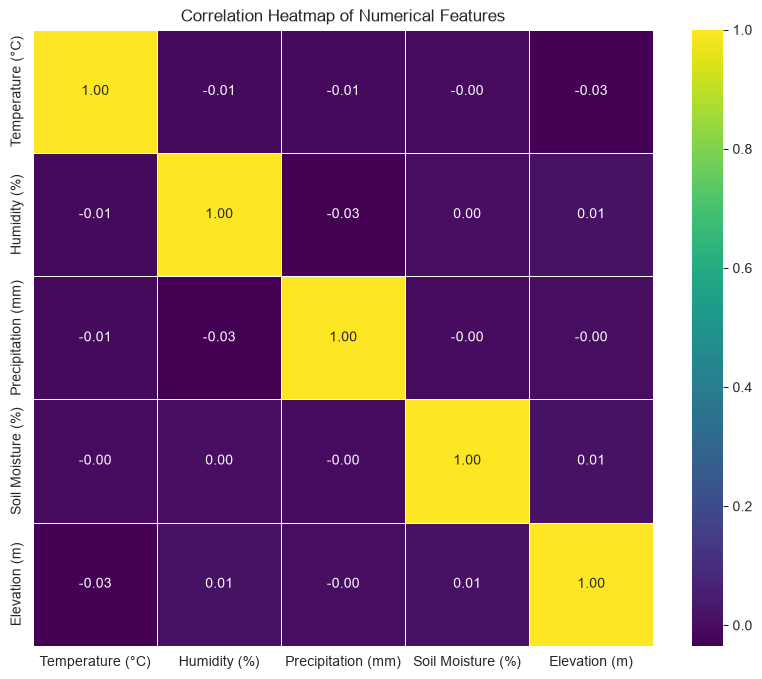

In [26]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='viridis', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## STEP 5 — PREPARE DATA FOR MACHINE LEARNING

In this step, we'll define our input features (the environmental factors) and our target variable (Landslide Risk Prediction). We'll also handle the categorical nature of our target by converting its labels into numerical values, which machine learning models can understand. Finally, we'll split our dataset into training and testing sets to properly evaluate our models, ensuring that the distribution of risk classes is maintained in both sets (stratified splitting).

In [27]:
# Define features (X) and target (y)
# The features are the environmental columns listed in your problem description.
# The target is 'Landslide Risk Prediction'.

FEATURES = [
    'Temperature (°C)',
    'Humidity (%)',
    'Precipitation (mm)',
    'Soil Moisture (%)',
    'Elevation (m)'
]

X = df[FEATURES]
y = df[TARGET_COLUMN] 

print(f'Features (X) shape: {X.shape}')
print(f'Target (y) shape: {y.shape}')

Features (X) shape: (5000, 5)
Target (y) shape: (5000,)


### Encoding Target Labels

Our target variable `Landslide Risk Prediction` is categorical (e.g., 'Low', 'Moderate'). Machine learning models typically require numerical input. Therefore, we use `LabelEncoder` from `sklearn.preprocessing` to convert these text labels into numerical values (e.g., Low -> 0, Moderate -> 1, etc.). It's very important to keep a record of this mapping so we can convert the model's numerical predictions back to human-readable risk categories later.

In [28]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the target variable
y_encoded = label_encoder.fit_transform(y)

# Display the mapping of original labels to encoded numbers
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print('Original Label to Encoded Value Mapping:')
print(label_mapping)

print('\nFirst 5 encoded target values:')
print(y_encoded[:5])

Original Label to Encoded Value Mapping:
{'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2), 'Very High': np.int64(3)}

First 5 encoded target values:
[1 1 1 1 1]


### Splitting Data into Training and Testing Sets

To evaluate our machine learning model fairly, we need to split our dataset into two parts:

1.  **Training data**: Used to train the model.
2.  **Testing data**: Used to evaluate the model's performance on unseen data.

We use `train_test_split` from `sklearn.model_selection`. The `stratify=y_encoded` argument is crucial here. It ensures that the proportion of each landslide risk class is roughly the same in both the training and testing sets. This is especially important for imbalanced datasets, like ours, to prevent the model from being trained or tested on a skewed distribution of classes.

We also use `random_state` for reproducibility, meaning if you run this code multiple times, you'll get the same split.

In [29]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# stratify=y_encoded ensures that the proportion of target classes is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

print('\nDistribution of target classes in training set:')
display(pd.Series(y_train).value_counts(normalize=True) * 100)

print('\nDistribution of target classes in testing set:')
display(pd.Series(y_test).value_counts(normalize=True) * 100)

X_train shape: (4000, 5)
X_test shape: (1000, 5)
y_train shape: (4000,)
y_test shape: (1000,)

Distribution of target classes in training set:


1    91.825
2     6.675
0     1.250
3     0.250
Name: proportion, dtype: float64


Distribution of target classes in testing set:


1    91.8
2     6.7
0     1.3
3     0.2
Name: proportion, dtype: float64

## STEP 6 — RANDOM FOREST MODEL

### What is a Random Forest?

A **Random Forest** is an ensemble machine learning algorithm. Think of it as a 'forest' made up of many individual 'decision trees'. Each tree in the forest makes its own prediction, and then the Random Forest combines these individual predictions (e.g., by taking a majority vote for classification) to produce a more accurate and stable final prediction.

### How it works:

1.  **Bootstrap Aggregation (Bagging)**: Each tree in the forest is trained on a random subset of the training data (with replacement). This helps to reduce variance and prevent overfitting.
2.  **Feature Randomness**: When building each tree, instead of considering all features to find the best split, only a random subset of features is considered. This introduces more diversity among the trees.
3.  **Voting/Averaging**: For classification tasks, the final prediction is determined by the class that gets the most 'votes' from all the individual trees. For regression, it's the average of the predictions.

### Why it is suitable for this tabular environmental dataset:

*   **Handles Non-linearity**: Random Forests can capture complex, non-linear relationships between environmental features and landslide risk without requiring specific assumptions about data distribution.
*   **Robust to Outliers**: Because it uses many trees and averages their predictions, a Random Forest is less sensitive to outliers in the data, which can be present in environmental measurements.
*   **Feature Importance**: It can inherently provide an estimate of feature importance, helping us understand which environmental factors are most influential in predicting landslide risk.
*   **Handles Imbalance**: With the `class_weight='balanced'` parameter, it can adjust for class imbalance in the target variable, which is important for our landslide risk prediction where 'High' and 'Very High' classes might be less frequent but more critical.

Now, let's train our Random Forest model.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Initialize the Random Forest Classifier
# class_weight='balanced' is used to handle class imbalance
# random_state for reproducibility
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Train the model on the training data
rf_model.fit(X_train, y_train)

print('Random Forest Model trained successfully!')

Random Forest Model trained successfully!


Now that our Random Forest model is trained, we can use it to make predictions on the test set. We'll generate both the predicted risk class (e.g., 'Low', 'High') and the probability of each risk class. The probabilities are crucial for understanding the model's confidence in its predictions and are often more informative than just the predicted class.

In [31]:
# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Get prediction probabilities for each class
# This gives an array where each row is a sample and columns are probabilities for each class
rf_probabilities = rf_model.predict_proba(X_test)

print('Sample of Random Forest Predictions (encoded):')
print(rf_predictions[:5])

print('\nSample of Random Forest Prediction Probabilities (first 5 for each class):')
# Display probabilities, mapping back to original labels for clarity
prob_df_rf = pd.DataFrame(rf_probabilities, columns=label_encoder.classes_)
display(prob_df_rf.head())

Sample of Random Forest Predictions (encoded):
[1 2 1 1 1]

Sample of Random Forest Prediction Probabilities (first 5 for each class):


,High,Low,Moderate,Very High
0,0.00,1.00,0.00,0.0
1,0.02,0.25,0.73,0.0
2,0.00,1.00,0.00,0.0
3,0.00,1.00,0.00,0.0
4,0.00,1.00,0.00,0.0


## STEP 7 — XGBOOST MODEL

### What is XGBoost?

XGBoost (eXtreme Gradient Boosting) is another powerful and widely used ensemble machine learning algorithm. Like Random Forest, it builds many individual models (decision trees), but it does so in a sequential, additive manner. Instead of each tree being independent, XGBoost builds new trees that try to correct the errors of previous trees.

### How it works:

1.  **Gradient Boosting**: It iteratively builds new trees, with each new tree attempting to correct the residual errors (the difference between actual and predicted values) of the previous tree ensemble.
2.  **Regularization**: XGBoost includes various regularization techniques (like L1 and L2 regularization) to prevent overfitting, making it robust and performant.
3.  **Parallel Processing**: While it builds trees sequentially, it optimizes the computation of internal tree structures to allow for parallel processing, making it very fast.
4.  **Handling Missing Values**: XGBoost can inherently handle missing values in the data without requiring explicit imputation.

### Why it can be useful for structured environmental data:

*   **High Performance**: XGBoost is known for its speed and accuracy, often outperforming other algorithms on structured datasets.
*   **Handles Complex Relationships**: It can effectively model intricate, non-linear relationships between environmental variables and landslide risk.
*   **Robustness**: Its regularization and handling of missing values make it a robust choice for real-world environmental data that might be noisy or incomplete.
*   **Scalability**: It's designed to be efficient, making it suitable for larger datasets if your data grows.

Now, let's train our XGBoost model.

In [32]:
import xgboost as xgb

# Initialize the XGBoost Classifier
# For multi-class classification, use 'multi:softmax' for predicted classes or 'multi:softprob' for probabilities.
# num_class is the number of unique classes in your target variable.
# scale_pos_weight can be used for imbalanced datasets, but XGBoost can handle it well implicitly.
# Use a reasonable initial learning rate and number of estimators.

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob', # For outputting probabilities
    num_class=len(label_encoder.classes_), # Number of unique risk classes
    eval_metric='mlogloss', # Evaluation metric for multi-class classification
    use_label_encoder=False, # Suppress the warning about deprecated use_label_encoder
    random_state=42 # For reproducibility
)

# Train the model on the training data
xgb_model.fit(X_train, y_train)

print('XGBoost Model trained successfully!')

XGBoost Model trained successfully!


/usr/local/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [09:05:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [33]:
import xgboost as xgb
print(xgb.__version__)

3.4.1


Similar to the Random Forest model, we will now use the trained XGBoost model to make predictions and get the probability for each landslide risk class on the test set. These probabilities will be crucial for the frontend team.

In [34]:
# Make predictions on the test set (returns encoded classes by default for 'multi:softmax' objective)
xgb_predictions = xgb_model.predict(X_test)

# Get prediction probabilities for each class
xgb_probabilities = xgb_model.predict_proba(X_test)

print('Sample of XGBoost Predictions (encoded):')
print(xgb_predictions[:5])

print('\nSample of XGBoost Prediction Probabilities (first 5 for each class):')
# Display probabilities, mapping back to original labels for clarity
prob_df_xgb = pd.DataFrame(xgb_probabilities, columns=label_encoder.classes_)
display(prob_df_xgb.head())

Sample of XGBoost Predictions (encoded):
[1 2 1 1 1]

Sample of XGBoost Prediction Probabilities (first 5 for each class):


,High,Low,Moderate,Very High
0,0.000044,0.999705,0.000243,0.000008
1,0.001129,0.010411,0.987765,0.000695
2,0.000012,0.999948,0.000037,0.000003
3,0.000010,0.999937,0.000050,0.000003
4,0.000017,0.999899,0.000081,0.000002


In [35]:
print("Classes:")
print(label_encoder.classes_)

Classes:
['High' 'Low' 'Moderate' 'Very High']


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import pandas as pd
import numpy as np

 
# RANDOM FOREST METRICS

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(
    y_test, rf_predictions,
    average='macro',
    zero_division=0
)
rf_recall = recall_score(
    y_test, rf_predictions,
    average='macro',
    zero_division=0
)
rf_f1 = f1_score(
    y_test, rf_predictions,
    average='macro',
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities,
    multi_class='ovr',
    average='macro'
)


 
# XGBOOST METRICS
 

xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(
    y_test, xgb_predictions,
    average='macro',
    zero_division=0
)
xgb_recall = recall_score(
    y_test, xgb_predictions,
    average='macro',
    zero_division=0
)
xgb_f1 = f1_score(
    y_test, xgb_predictions,
    average='macro',
    zero_division=0
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_probabilities,
    multi_class='ovr',
    average='macro'
)


 
# MODEL COMPARISON TABLE
 
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy],
    'Precision (Macro)': [rf_precision, xgb_precision],
    'Recall (Macro)': [rf_recall, xgb_recall],
    'F1 Score (Macro)': [rf_f1, xgb_f1],
    'ROC-AUC (Macro OVR)': [rf_auc, xgb_auc]
})

display(model_comparison.round(4))

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),ROC-AUC (Macro OVR)
0,Random Forest,0.999,0.9821,0.9997,0.9906,1.0
1,XGBoost,1.000,1.0000,1.0000,1.0000,1.0


In [37]:
print(" RANDOM FOREST CLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


print("\n XGBOOST CLASSIFICATION REPORT ")

print(
    classification_report(
        y_test,
        xgb_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

 RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       0.93      1.00      0.96        13
         Low       1.00      1.00      1.00       918
    Moderate       1.00      1.00      1.00        67
   Very High       1.00      1.00      1.00         2

    accuracy                           1.00      1000
   macro avg       0.98      1.00      0.99      1000
weighted avg       1.00      1.00      1.00      1000


 XGBOOST CLASSIFICATION REPORT 
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        13
         Low       1.00      1.00      1.00       918
    Moderate       1.00      1.00      1.00        67
   Very High       1.00      1.00      1.00         2

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



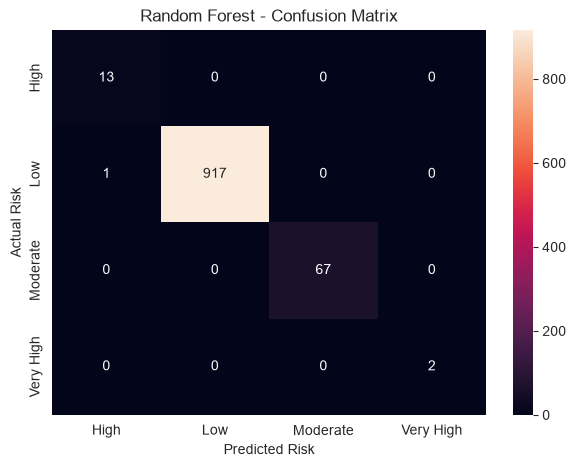

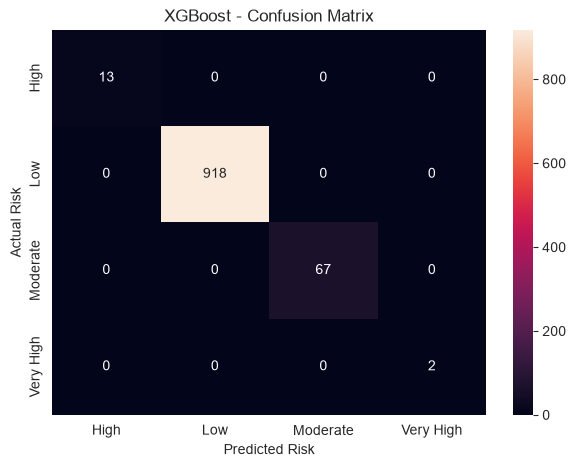

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest confusion matrix
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("Random Forest - Confusion Matrix")
plt.show()


# XGBoost confusion matrix
xgb_cm = confusion_matrix(y_test, xgb_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [39]:
# Select model based on Macro F1 score

if xgb_f1 >= rf_f1:
    final_model = xgb_model
    final_predictions = xgb_predictions
    final_probabilities = xgb_probabilities
    selected_model_name = "XGBoost"
else:
    final_model = rf_model
    final_predictions = rf_predictions
    final_probabilities = rf_probabilities
    selected_model_name = "Random Forest"

print("Selected model:", selected_model_name)
print("Macro F1 Score:", max(xgb_f1, rf_f1))

Selected model: XGBoost
Macro F1 Score: 1.0


### OpenWeatherMap prediction

In [40]:
# api key and url
API_KEY = "648a165bcef4a847f468e06a213eb0b6"

city = "Guwahati"
country = "IN"

url = "https://api.openweathermap.org/data/2.5/weather"

params = {
    "q": f"{city},{country}",
    "appid": API_KEY,
    "units": "metric"
}

In [41]:
# call the api
response = requests.get(url, params=params)

print("Status code:", response.status_code)

weather_data = response.json()
weather_data

Status code: 200


{'coord': {'lon': 91.751, 'lat': 26.1862},
 'weather': [{'id': 803,
   'main': 'Clouds',
   'description': 'broken clouds',
   'icon': '04d'}],
 'base': 'stations',
 'main': {'temp': 28.95,
  'feels_like': 35.48,
  'temp_min': 28.95,
  'temp_max': 28.95,
  'pressure': 1011,
  'humidity': 84,
  'sea_level': 1011,
  'grnd_level': 998},
 'visibility': 10000,
 'wind': {'speed': 0, 'deg': 0},
 'clouds': {'all': 68},
 'dt': 1789702550,
 'sys': {'type': 1,
  'id': 9117,
  'country': 'IN',
  'sunrise': 1789688385,
  'sunset': 1789732502},
 'timezone': 19800,
 'id': 1271476,
 'name': 'Guwahati',
 'cod': 200}

In [42]:
# extract wheather data
temperature = weather_data["main"]["temp"]
humidity = weather_data["main"]["humidity"]

rainfall = weather_data.get("rain", {}).get("1h", 0)

print("Temperature:", temperature, "°C")
print("Humidity:", humidity, "%")
print("Rainfall:", rainfall, "mm")

Temperature: 28.95 °C
Humidity: 84 %
Rainfall: 0 mm


In [43]:
soil_moisture = 70
elevation = 500

print("Soil Moisture:", soil_moisture, "%")
print("Elevation:", elevation, "m")

Soil Moisture: 70 %
Elevation: 500 m


In [44]:
live_input = pd.DataFrame({
    'Temperature (°C)': [temperature],
    'Humidity (%)': [humidity],
    'Precipitation (mm)': [rainfall],
    'Soil Moisture (%)': [soil_moisture],
    'Elevation (m)': [elevation]
})

display(live_input)

,Temperature (°C),Humidity (%),Precipitation (mm),Soil Moisture (%),Elevation (m)
0,28.95,84,0,70,500


In [45]:
 
# FINAL PREDICTION DATAFRAME
 
final_prediction_df = X_test.copy()

# Actual risk
final_prediction_df['Actual_Risk'] = label_encoder.inverse_transform(y_test)

# Predicted risk
final_prediction_df['Predicted_Risk'] = label_encoder.inverse_transform(
    final_predictions.astype(int)
)

# Probability associated with the predicted class
final_prediction_df['Risk_Probability'] = np.max(
    final_probabilities,
    axis=1
)

# Risk level
final_prediction_df['Risk_Level'] = final_prediction_df['Predicted_Risk']


# Risk color mapping
risk_color_map = {
    'Low': 'Green',
    'Moderate': 'Yellow',
    'High': 'Orange',
    'Very High': 'Red'
}

final_prediction_df['Risk_Color'] = (
    final_prediction_df['Risk_Level'].map(risk_color_map)
)

print("Final prediction DataFrame:")
display(final_prediction_df.head(10))

Final prediction DataFrame:


,Temperature (°C),Humidity (%),Precipitation (mm),Soil Moisture (%),Elevation (m),Actual_Risk,Predicted_Risk,Risk_Probability,Risk_Level,Risk_Color
1716,29,64,127,69,953,Low,Low,0.999705,Low,Green
2256,33,89,184,61,682,Moderate,Moderate,0.987765,Moderate,Yellow
3248,16,55,122,40,785,Low,Low,0.999948,Low,Green
125,26,69,211,28,543,Low,Low,0.999937,Low,Green
1476,16,60,58,74,684,Low,Low,0.999899,Low,Green
3433,26,30,69,72,521,Low,Low,0.999917,Low,Green
3,25,53,136,70,583,Low,Low,0.999720,Low,Green
2286,34,72,75,49,607,Low,Low,0.999952,Low,Green
486,20,67,6,88,331,Low,Low,0.999919,Low,Green
2140,17,45,197,69,196,Low,Low,0.999888,Low,Green


In [48]:
live_prediction = final_model.predict(live_input)
live_probability = final_model.predict_proba(live_input)

predicted_risk = label_encoder.inverse_transform(
    live_prediction.astype(int)
)[0]

predicted_probability = live_probability[0, live_prediction[0]]

print("Predicted Risk:", predicted_risk)
print("Probability:", round(predicted_probability, 4))

Predicted Risk: Low
Probability: 0.9991


In [46]:
print("Shape:", final_prediction_df.shape)

print("\nColumns:")
print(final_prediction_df.columns.tolist())

print("\nRisk level counts:")
print(final_prediction_df['Risk_Level'].value_counts())

display(final_prediction_df.head(20))

Shape: (1000, 10)

Columns:
['Temperature (°C)', 'Humidity (%)', 'Precipitation (mm)', 'Soil Moisture (%)', 'Elevation (m)', 'Actual_Risk', 'Predicted_Risk', 'Risk_Probability', 'Risk_Level', 'Risk_Color']

Risk level counts:
Risk_Level
Low          918
Moderate      67
High          13
Very High      2
Name: count, dtype: int64


,Temperature (°C),Humidity (%),Precipitation (mm),Soil Moisture (%),Elevation (m),Actual_Risk,Predicted_Risk,Risk_Probability,Risk_Level,Risk_Color
1716,29,64,127,69,953,Low,Low,0.999705,Low,Green
2256,33,89,184,61,682,Moderate,Moderate,0.987765,Moderate,Yellow
3248,16,55,122,40,785,Low,Low,0.999948,Low,Green
125,26,69,211,28,543,Low,Low,0.999937,Low,Green
1476,16,60,58,74,684,Low,Low,0.999899,Low,Green
3433,26,30,69,72,521,Low,Low,0.999917,Low,Green
3,25,53,136,70,583,Low,Low,0.999720,Low,Green
2286,34,72,75,49,607,Low,Low,0.999952,Low,Green
486,20,67,6,88,331,Low,Low,0.999919,Low,Green
2140,17,45,197,69,196,Low,Low,0.999888,Low,Green


In [49]:
risk_color_map = {
    'Low': 'Green',
    'Moderate': 'Yellow',
    'High': 'Orange',
    'Very High': 'Red'
}

risk_color = risk_color_map[predicted_risk]

print("Risk Color:", risk_color)

Risk Color: Green


In [47]:
final_prediction_df.to_csv(
    'landslide_predictions.csv',
    index=False
)

print("CSV created successfully!")
print("File name: landslide_predictions.csv")

CSV created successfully!
File name: landslide_predictions.csv
